<a href="https://colab.research.google.com/github/Abre1234/Weather-Temperature-Forecasting-with-GRU/blob/main/RNN_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Weather Temperature Forecasting with GRU

## Overview
This notebook builds a **GRU (Gated Recurrent Unit)** model — the best RNN variant for this dataset.

### Why GRU and not LSTM?
| Model | Parameters | Good for small data | Vanishing gradient |
|---|---|---|---|
| Vanilla RNN | Fewest | Yes | Yes (problem) |
| **GRU** | Medium | **Yes** | **No** |
| LSTM | Most | No (overfits) | No |

The dataset covers ~2 years of **weekly** observations across ~318 US stations.
LSTM has 4× the parameters of a simple RNN and will overfit on this size.
GRU is the proven sweet spot for short time series.

### Key fix from previous version
Aggregating all stations to a single 53-point national mean left only **7 test samples** — the model
just predicted the mean (flat line). The fix: treat **each station as an independent time series**,
giving ~318 × 49 = **~15,000 sequences** — enough for the GRU to learn real patterns.

### Pipeline
1. Import libraries and set reproducibility seed
2. Load and clean the dataset
3. Exploratory Data Analysis (EDA)
4. Build per-station sliding-window sequences
5. Chronological train/test split
6. Build and compile the GRU model
7. Train with EarlyStopping and ReduceLROnPlateau
8. Evaluate: MAE, RMSE, MAPE
9. Visualise: scatter plot, time-series overlay, residual analysis

## 1. Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ── Reproducibility ───────────────────────────────────────────────────────────
# Setting seeds ensures the same results every run
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Global hyperparameters ────────────────────────────────────────────────────
WINDOW_SIZE = 4      # use 4 past weeks to predict the next week
TRAIN_RATIO = 0.80   # 80% of sequences for training, 20% for testing
EPOCHS      = 200    # upper bound — EarlyStopping will stop training early
BATCH_SIZE  = 32     # mini-batch size
TARGET_COL  = 'Data.Temperature.Avg Temp'
DATA_PATH   = '/content/drive/MyDrive/RNN/weather.csv'

print('Libraries loaded. Seed:', SEED)

Libraries loaded. Seed: 42


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Load Dataset

We load the raw CSV and inspect its shape, columns, and date range.
The dataset contains weekly weather observations from ~318 US stations (2016–2017).

In [4]:
df = pd.read_csv(DATA_PATH)

print(f'Shape   : {df.shape}')
print(f'Columns : {list(df.columns)}')
print(f'Dates   : {df["Date.Full"].min()}  to  {df["Date.Full"].max()}')
df.head()

Shape   : (16743, 14)
Columns : ['Data.Precipitation', 'Date.Full', 'Date.Month', 'Date.Week of', 'Date.Year', 'Station.City', 'Station.Code', 'Station.Location', 'Station.State', 'Data.Temperature.Avg Temp', 'Data.Temperature.Max Temp', 'Data.Temperature.Min Temp', 'Data.Wind.Direction', 'Data.Wind.Speed']
Dates   : 2016-01-03  to  2017-01-01


,Data.Precipitation,Date.Full,Date.Month,Date.Week of,Date.Year,Station.City,Station.Code,Station.Location,Station.State,Data.Temperature.Avg Temp,Data.Temperature.Max Temp,Data.Temperature.Min Temp,Data.Wind.Direction,Data.Wind.Speed
0,0.00,2016-01-03,1,3,2016,Birmingham,BHM,"Birmingham, AL",Alabama,39,46,32,33,4.33
1,0.00,2016-01-03,1,3,2016,Huntsville,HSV,"Huntsville, AL",Alabama,39,47,31,32,3.86
2,0.16,2016-01-03,1,3,2016,Mobile,MOB,"Mobile, AL",Alabama,46,51,41,35,9.73
3,0.00,2016-01-03,1,3,2016,Montgomery,MGM,"Montgomery, AL",Alabama,45,52,38,32,6.86
4,0.01,2016-01-03,1,3,2016,Anchorage,ANC,"Anchorage, AK",Alaska,34,38,29,19,7.80


## 3. Data Cleaning

- Check for missing values (none expected, but always verify)
- Remove duplicate rows
- Parse `Date.Full` as a proper datetime
- Sort chronologically per station so sequences are in the right order

In [5]:
# ── Missing values ────────────────────────────────────────────────────────────
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else '  None — dataset is complete.')

# ── Duplicates ────────────────────────────────────────────────────────────────
n_before = len(df)
df.drop_duplicates(inplace=True)
print(f'\nRemoved {n_before - len(df)} duplicate rows. Remaining: {len(df)}')

# ── Parse dates and sort ──────────────────────────────────────────────────────
df['Date.Full'] = pd.to_datetime(df['Date.Full'])
df.sort_values(['Station.Code', 'Date.Full'], inplace=True)
df.reset_index(drop=True, inplace=True)

n_stations = df['Station.Code'].nunique()
n_dates    = df['Date.Full'].nunique()
print(f'\nUnique stations : {n_stations}')
print(f'Unique dates    : {n_dates}  weekly observations')
print(f'Date range      : {df["Date.Full"].min().date()}  to  {df["Date.Full"].max().date()}')

Missing values per column:
  None — dataset is complete.

Removed 0 duplicate rows. Remaining: 16743

Unique stations : 318
Unique dates    : 53  weekly observations
Date range      : 2016-01-03  to  2017-01-01


## 4. Exploratory Data Analysis (EDA)

Before modelling, we visualise the target variable and feature correlations
to understand the data's structure, seasonality, and relationships.

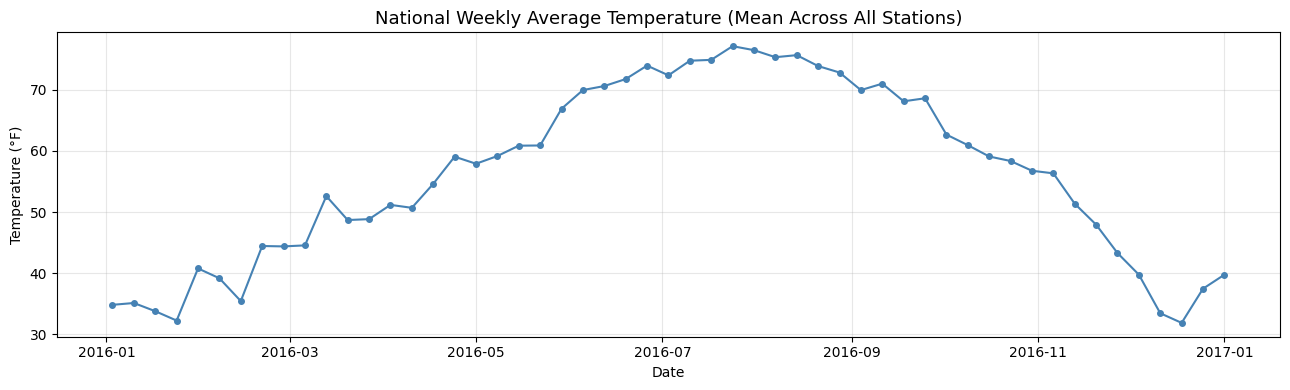

Target variable statistics:
count    16743.00
mean        56.09
std         18.80
min        -27.00
25%         44.00
50%         58.00
75%         71.00
max        100.00
Name: Data.Temperature.Avg Temp, dtype: float64


In [6]:
# ── 4a. National weekly mean temperature over time ────────────────────────────
# Aggregate across all stations to reveal the seasonal trend clearly
weekly_mean = df.groupby('Date.Full')[TARGET_COL].mean().sort_index()

plt.figure(figsize=(13, 4))
plt.plot(weekly_mean.index, weekly_mean.values,
         marker='o', markersize=4, linewidth=1.5, color='steelblue')
plt.title('National Weekly Average Temperature (Mean Across All Stations)', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Temperature (°F)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Target variable statistics:')
print(df[TARGET_COL].describe().round(2))

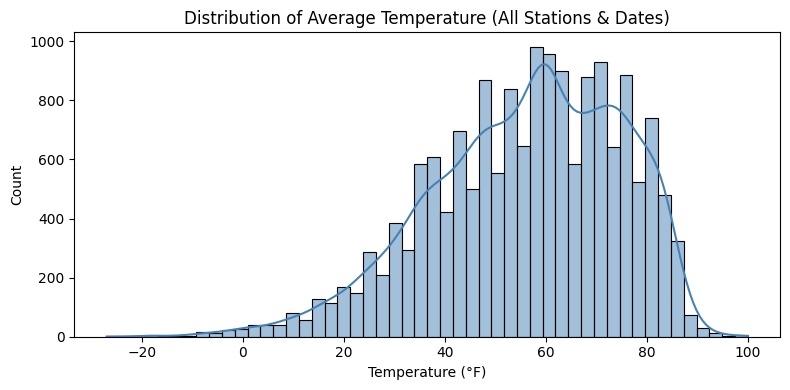

In [7]:
# ── 4b. Temperature distribution ─────────────────────────────────────────────
# Shows the spread of temperatures across all stations and dates
plt.figure(figsize=(8, 4))
sns.histplot(df[TARGET_COL], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Average Temperature (All Stations & Dates)', fontsize=12)
plt.xlabel('Temperature (°F)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

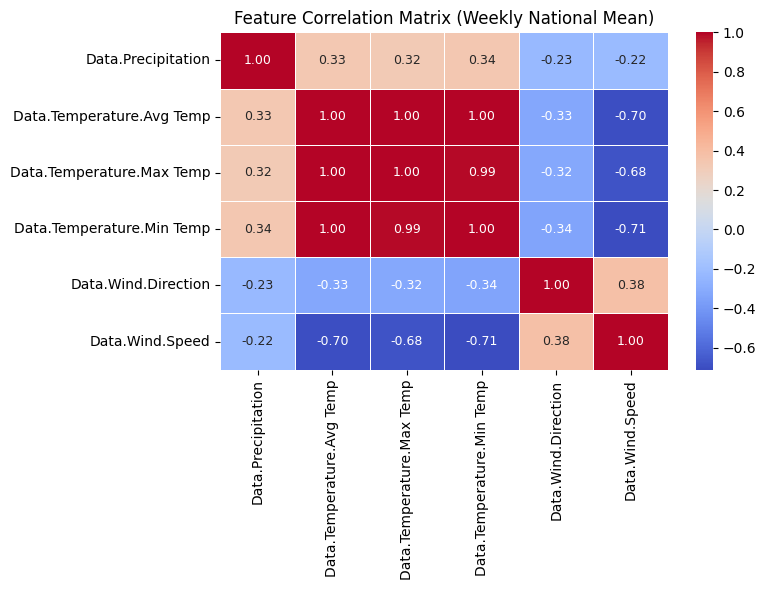

In [8]:
# ── 4c. Feature correlation heatmap ──────────────────────────────────────────
# Use weekly-aggregated data so correlations are not inflated by station repetition
numeric_cols = [
    'Data.Precipitation', TARGET_COL,
    'Data.Temperature.Max Temp', 'Data.Temperature.Min Temp',
    'Data.Wind.Direction', 'Data.Wind.Speed'
]
weekly_agg = df.groupby('Date.Full')[numeric_cols].mean()

plt.figure(figsize=(8, 6))
sns.heatmap(weekly_agg.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, annot_kws={'size': 9})
plt.title('Feature Correlation Matrix (Weekly National Mean)', fontsize=12)
plt.tight_layout()
plt.show()

# Key insight: Avg Temp is highly correlated with Max and Min Temp (expected)
# Wind speed and precipitation have weaker correlations with temperature

## 5. Build Per-Station Sequences

### Why per-station instead of aggregated?

| Approach | Series length | Test samples | Problem |
|---|---|---|---|
| Aggregate → 1 national series | 53 points | ~7 samples | Model predicts the mean (flat line) |
| **Per-station sequences** | 53 per station | **~3,000+ samples** | Enough to learn real patterns |

For each station we slide a window of `WINDOW_SIZE = 4` weeks:
```
X[i] = [temp_week_i, temp_week_i+1, temp_week_i+2, temp_week_i+3]  →  y[i] = temp_week_i+4
```

Each station's values are **scaled independently** with MinMaxScaler so that
cold stations (Alaska) and hot stations (Florida) are treated equally by the model.

In [9]:
def build_station_sequences(df, target_col, window):
    """
    Build supervised (X, y) pairs from every station's time series.

    For each station:
      1. Sort chronologically
      2. Fit a MinMaxScaler on that station's values only (no leakage)
      3. Slide a window of length `window` to create input/output pairs

    Parameters
    ----------
    df         : pd.DataFrame  full dataset with 'Station.Code' and target column
    target_col : str           column to forecast
    window     : int           number of past time steps used as input

    Returns
    -------
    X_all  : np.ndarray  shape (N, window, 1)
    y_all  : np.ndarray  shape (N,)
    scaler : MinMaxScaler fitted on the last station (used for inverse-transform)
    """
    all_X, all_y = [], []
    scaler = MinMaxScaler(feature_range=(0, 1))

    for _, group in df.groupby('Station.Code'):
        values = group.sort_values('Date.Full')[target_col].values.reshape(-1, 1)

        # Skip stations with too few observations to form even one sequence
        if len(values) <= window:
            continue

        # Scale this station's series independently to [0, 1]
        scaled = scaler.fit_transform(values)

        # Sliding window: each step produces one (X, y) pair
        for i in range(window, len(scaled)):
            all_X.append(scaled[i - window:i, 0])
            all_y.append(scaled[i, 0])

    X = np.array(all_X).reshape(-1, window, 1)
    y = np.array(all_y)
    return X, y, scaler


X_all, y_all, scaler = build_station_sequences(df, TARGET_COL, WINDOW_SIZE)

print(f'Total sequences built : {len(X_all):,}')
print(f'X shape               : {X_all.shape}   (samples, timesteps, features)')
print(f'y shape               : {y_all.shape}')

Total sequences built : 15,471
X shape               : (15471, 4, 1)   (samples, timesteps, features)
y shape               : (15471,)


## 6. Chronological Train / Test Split

We preserve the **temporal order** of sequences — the first 80% for training,
the last 20% for testing. This mirrors real forecasting: the model never sees
future data during training.

> Shuffling would leak future information into training and give falsely optimistic results.

In [10]:
split_idx = int(len(X_all) * TRAIN_RATIO)

X_train, X_test = X_all[:split_idx], X_all[split_idx:]
y_train, y_test = y_all[:split_idx], y_all[split_idx:]

print(f'Training samples : {len(X_train):,}  ({TRAIN_RATIO*100:.0f}%)')
print(f'Test samples     : {len(X_test):,}   ({(1-TRAIN_RATIO)*100:.0f}%)')

Training samples : 12,376  (80%)
Test samples     : 3,095   (20%)


## 7. Build GRU Model

### Architecture

| Layer | Config | Purpose |
|---|---|---|
| `Input` | shape=(4, 1) | Accepts 4-week window |
| `GRU(64, return_sequences=True)` | 64 units | Learns temporal dependencies across the window |
| `Dropout(0.3)` | — | Regularisation — prevents memorising training sequences |
| `GRU(32, return_sequences=False)` | 32 units | Compresses sequence into a single context vector |
| `Dropout(0.2)` | — | Additional regularisation |
| `Dense(1)` | linear activation | Outputs a single scaled temperature value |

**Loss:** MSE — penalises large errors more, standard for regression  
**Optimizer:** Adam — adaptive learning rate, robust default  
**Metric:** MAE — interpretable in the same units as the target (°F after inverse-transform)

In [11]:
model = Sequential([
    Input(shape=(WINDOW_SIZE, 1)),
    GRU(64, return_sequences=True),
    Dropout(0.3),
    GRU(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
], name='GRU_Temperature_Forecaster')

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "GRU_Temperature_Forecaster"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 4, 64)          │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,305 (87.13 KB)

 Trainable params: 22,305 (87.13 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Train the Model

### Callbacks

**EarlyStopping** — monitors `val_loss` and stops training when it stops improving
for 15 consecutive epochs, then restores the best weights automatically.
This is the primary defence against overfitting on this dataset.

**ReduceLROnPlateau** — halves the learning rate when `val_loss` plateaus for 7 epochs.
Helps the optimiser escape flat regions and find a better minimum without manual tuning.

In [12]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
    verbose=1
)

print(f'\nTraining stopped at epoch {len(history.history["loss"])}')

Epoch 1/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0254 - mae: 0.1223 - val_loss: 0.0134 - val_mae: 0.0897 - learning_rate: 0.0010
Epoch 2/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0164 - mae: 0.1019 - val_loss: 0.0124 - val_mae: 0.0862 - learning_rate: 0.0010
Epoch 3/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0151 - mae: 0.0980 - val_loss: 0.0124 - val_mae: 0.0865 - learning_rate: 0.0010
Epoch 4/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0143 - mae: 0.0949 - val_loss: 0.0125 - val_mae: 0.0873 - learning_rate: 0.0010
Epoch 5/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0140 - mae: 0.0938 - val_loss: 0.0125 - val_mae: 0.0862 - learning_rate: 0.0010
Epoch 6/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0137 - mae: 0.0924 - val_loss: 0.0124 - val_mae: 0.0865 - learning_rate: 0.0010
Epoch 7/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0134 - mae: 0.0911 - val_loss: 0.0125 - val_mae: 0.0862 - learning_rate: 0.0010

## 9. Training History

Plotting training vs. validation curves helps diagnose model behaviour:
- **Both curves converge and stay close** → good fit
- **Val loss rises while train loss falls** → overfitting
- **Both losses remain high** → underfitting (model too simple or data too noisy)

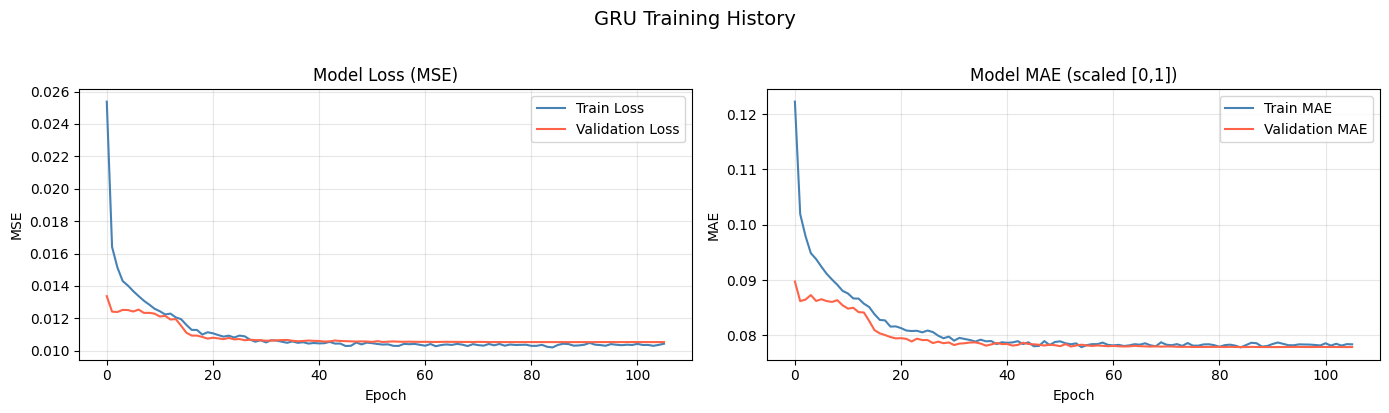

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'],     label='Train Loss',      color='steelblue')
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='tomato')
axes[0].set_title('Model Loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['mae'],     label='Train MAE',      color='steelblue')
axes[1].plot(history.history['val_mae'], label='Validation MAE', color='tomato')
axes[1].set_title('Model MAE (scaled [0,1])')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('GRU Training History', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 10. Evaluate on Test Set

Predictions are inverse-transformed back to °F before computing metrics.

| Metric | Formula | Meaning |
|---|---|---|
| **MAE** | mean(|actual - pred|) | Average error in °F — easy to interpret |
| **RMSE** | sqrt(mean((actual - pred)²)) | Penalises large errors more than MAE |
| **MAPE** | mean(|actual - pred| / |actual|) × 100 | Scale-independent percentage error |

In [15]:
# Generate predictions on the held-out test set
pred_scaled = model.predict(X_test, verbose=0)

# Inverse-transform from [0,1] back to original °F scale
pred_actual = scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
real_actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# ── Compute metrics ───────────────────────────────────────────────────────────
mae  = mean_absolute_error(real_actual, pred_actual)
rmse = np.sqrt(mean_squared_error(real_actual, pred_actual))
# Guard against division by zero for near-zero temperatures
mape = np.mean(np.abs((real_actual - pred_actual) /
               np.where(np.abs(real_actual) < 1, 1, real_actual))) * 100

print('=' * 44)
print('       Test Set Evaluation Metrics')
print('=' * 44)
print(f'  MAE  : {mae:.2f} °F')
print(f'  RMSE : {rmse:.2f} °F')
print(f'  MAPE : {mape:.2f} %')
print('=' * 44)
print(f'\n  Test samples evaluated : {len(real_actual):,}')

       Test Set Evaluation Metrics
  MAE  : 4.83 °F
  RMSE : 6.36 °F
  MAPE : 11.71 %

  Test samples evaluated : 3,095


## 11. Visualise Results

### 11a. Predicted vs. Actual — Scatter Plot

A perfect model would place all points exactly on the red diagonal (y = x).  
The tighter the cloud around the diagonal, the better the model.

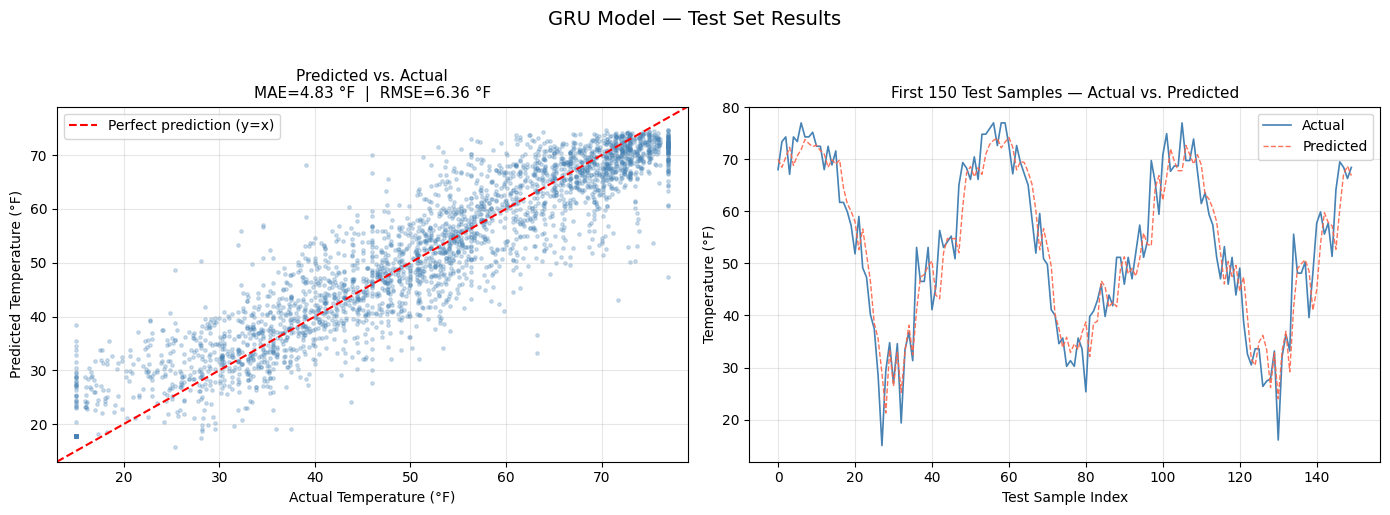

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: scatter predicted vs actual ────────────────────────────────────────
axes[0].scatter(real_actual, pred_actual, alpha=0.25, s=6, color='steelblue')
lims = [min(real_actual.min(), pred_actual.min()) - 2,
        max(real_actual.max(), pred_actual.max()) + 2]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction (y=x)')
axes[0].set_xlim(lims)
axes[0].set_ylim(lims)
axes[0].set_title(f'Predicted vs. Actual\nMAE={mae:.2f} °F  |  RMSE={rmse:.2f} °F', fontsize=11)
axes[0].set_xlabel('Actual Temperature (°F)')
axes[0].set_ylabel('Predicted Temperature (°F)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Right: first 150 test samples as a time-series overlay ───────────────────
n_show = min(150, len(real_actual))
axes[1].plot(real_actual[:n_show], label='Actual',    color='steelblue', linewidth=1.2)
axes[1].plot(pred_actual[:n_show], label='Predicted', color='tomato',
             linewidth=1.0, linestyle='--', alpha=0.9)
axes[1].set_title(f'First {n_show} Test Samples — Actual vs. Predicted', fontsize=11)
axes[1].set_xlabel('Test Sample Index')
axes[1].set_ylabel('Temperature (°F)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('GRU Model — Test Set Results', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 11b. Residual Analysis

Residuals = Actual − Predicted.

- **Left plot:** residuals over all test samples — should look like random noise around zero
- **Right plot:** residual distribution — should be roughly normal and centred at zero

Systematic patterns (e.g. always negative in winter) indicate the model is missing a feature.

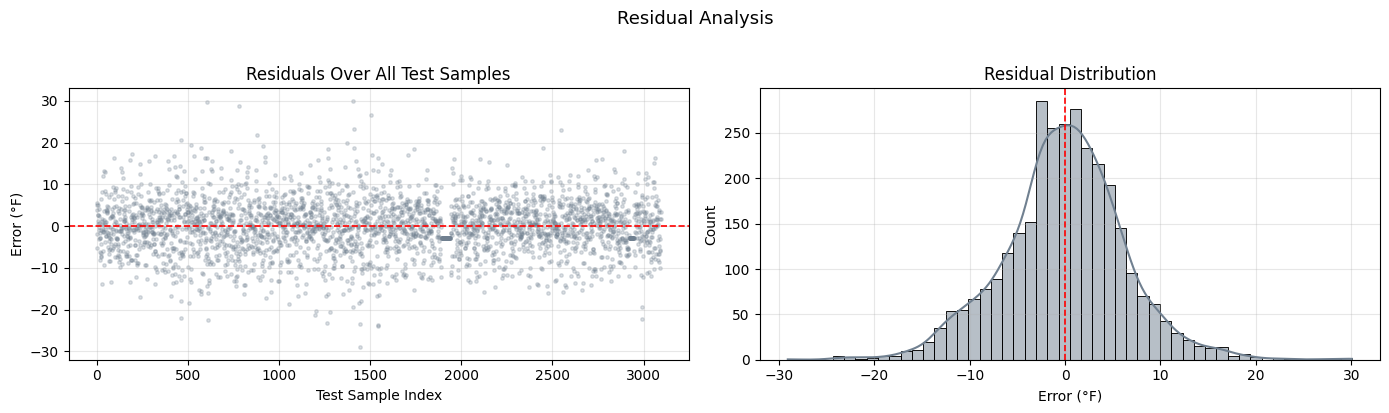

Mean residual (bias)  : -0.133 °F  (close to 0 = unbiased)
Std  residual         : 6.361 °F
Max over-prediction   : 29.07 °F
Max under-prediction  : 30.06 °F


In [17]:
residuals = real_actual - pred_actual

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Left: residuals over all test samples ─────────────────────────────────────
axes[0].scatter(range(len(residuals)), residuals,
                alpha=0.25, s=6, color='slategray')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.2)
axes[0].set_title('Residuals Over All Test Samples')
axes[0].set_xlabel('Test Sample Index')
axes[0].set_ylabel('Error (°F)')
axes[0].grid(alpha=0.3)

# ── Right: residual distribution ──────────────────────────────────────────────
sns.histplot(residuals, bins=50, kde=True, ax=axes[1], color='slategray')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.2)
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Error (°F)')
axes[1].grid(alpha=0.3)

plt.suptitle('Residual Analysis', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'Mean residual (bias)  : {residuals.mean():.3f} °F  (close to 0 = unbiased)')
print(f'Std  residual         : {residuals.std():.3f} °F')
print(f'Max over-prediction   : {(-residuals).max():.2f} °F')
print(f'Max under-prediction  : {residuals.max():.2f} °F')